In [2]:
import os
import tempfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import seaborn as sns
from scvi.external import MRVI
from plotnine import *
import xarray as xr
from PyComplexHeatmap import ClusterMapPlotter, HeatmapAnnotation, anno_simple, anno_label

In [3]:
# ==============================================================================
# 1. LOAD DATA & MODELS
# ==============================================================================

# Load AnnData object
adata = sc.read_h5ad("/mnt/data/melina/adata_all_batch_Epithelial.h5ad")

# Load MRVI Model (final mrvi model from job 171, sample_key = sample_ID, batch_key = donor)
model_mrvi = MRVI.load("/mnt/data/melina/models/mrvi_model_Epithelial", adata=adata)

# Load DE results dataset
dmats = xr.open_dataset("/mnt/data/melina/deg_Epithelial_uc_control_baseline.nc")
ds = dmats
de_res = dmats

# Inspect the structure (dimensions, coordinates, and variables)
print(ds)

INFO     File /mnt/data/melina/models/mrvi_model_Epithelial/model.pt already downloaded                            


/tmp/ipykernel_1897463/3929229788.py:9: UserWarning: MRVI model is being loaded with PyTorch backend
/home/melrie/miniforge3/envs/hi/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/melrie/miniforge3/envs/hi/lib/python3.13/site- ...


<xarray.Dataset> Size: 100GB
Dimensions:      (cell_name: 71638, covariate: 4, latent_dim: 30, gene: 29001)
Coordinates:
  * cell_name    (cell_name) <U39 11MB 'AAACGGGAGGCCATAG-Pan_T7917821' ... 'T...
  * covariate    (covariate) <U48 768B 'donor_disease_category_pediatric_heal...
  * latent_dim   (latent_dim) int64 240B 0 1 2 3 4 5 6 ... 23 24 25 26 27 28 29
  * gene         (gene) <U16 2MB 'OR4F5' 'AL627309.3' ... 'AC007325.2'
Data variables:
    beta         (cell_name, covariate, latent_dim) float32 34MB ...
    effect_size  (cell_name, covariate) float32 1MB ...
    pvalue       (cell_name, covariate) float32 1MB ...
    padj         (cell_name, covariate) float32 1MB ...
    n_samples    (cell_name) int64 573kB ...
    lfc          (cell_name, covariate, gene) float32 33GB ...
    lfc_std      (cell_name, covariate, gene) float32 33GB ...
    pde          (cell_name, covariate, gene) float32 33GB ...


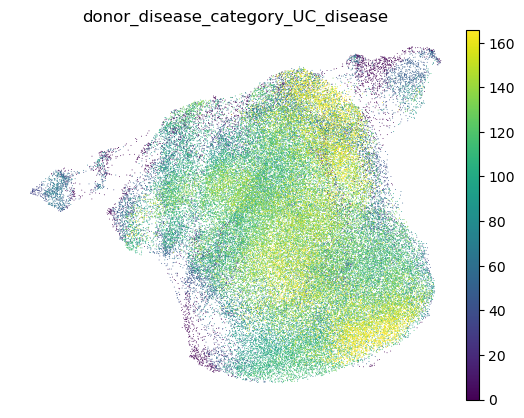

/tmp/ipykernel_1897463/3899410575.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



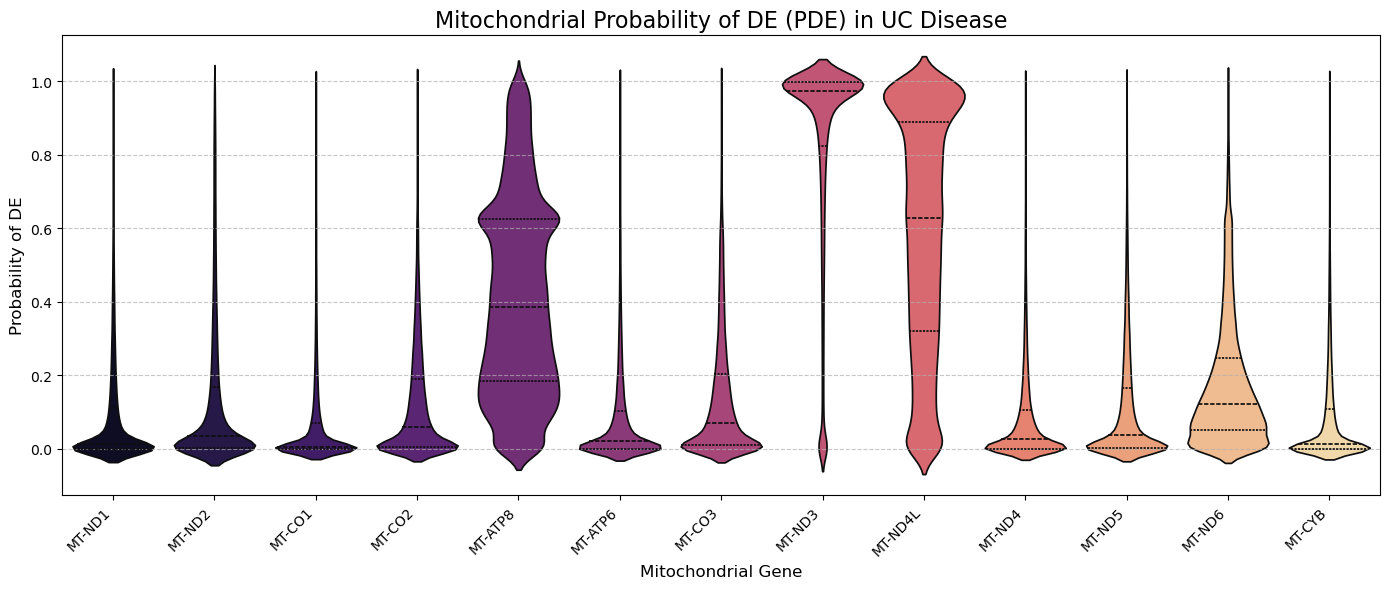

In [4]:



# ==============================================================================
# 2. MAP EFFECT SIZE & PLOT UMAP
# ==============================================================================

# Define your comparison group
comp_group = ["donor_disease_category_UC_disease"]

for i in comp_group:
    # Map the effect size to observations (Ensure alignment matches adata.obs_names)
    adata.obs[i] = de_res.effect_size.sel(covariate=i).values

# Calculate a robust max for the color scale of the effect size
vmax_val = float(np.nanquantile(adata.obs["donor_disease_category_UC_disease"], 0.95))

# Plot UMAP embedding with mapped effect sizes
sc.pl.embedding(
    adata,
    basis="umap_mrvi_u",
    color=["donor_disease_category_UC_disease"],
    ncols=2,                   # Kept at 2 for optimized side-by-side comparison
    layer="data",              # CRITICAL: Ensures the layer data is targeted correctly
    cmap="viridis", 
    vmax=vmax_val,             # Correctly mapping your 95th percentile robust max threshold
    frameon=False
)


# ==============================================================================
# 3. MITOCHONDRIAL PDE VIOLIN PLOT
# ==============================================================================

# Automatically identify mitochondrial genes present in your specific dataset
mt_genes = [g for g in adata.var_names if g.upper().startswith('MT-')]

# Identify the specific covariate string for UC_disease
target_cov = "donor_disease_category_UC_disease"

# Slice the dataset for MT genes AND the specific covariate
mt_pde_uc = ds['pde'].sel(gene=mt_genes, covariate=target_cov)

# Convert to a standard DataFrame for Seaborn plotting
mt_pde_df_uc = mt_pde_uc.to_dataframe(name='pde_value').reset_index()

# Create the Plot
plt.figure(figsize=(14, 6))
sns.violinplot(
    data=mt_pde_df_uc, 
    x='gene', 
    y='pde_value', 
    inner='quartile', 
    palette='magma'
)

# Aesthetics
plt.title('Mitochondrial Probability of DE (PDE) in UC Disease', fontsize=16)
plt.ylabel("Probability of DE", fontsize=12)
plt.xlabel("Mitochondrial Gene", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

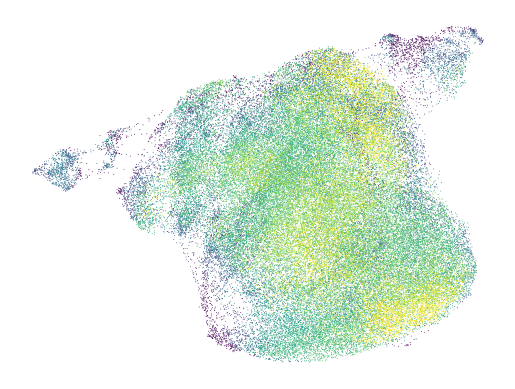

/tmp/ipykernel_1897463/1025289919.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



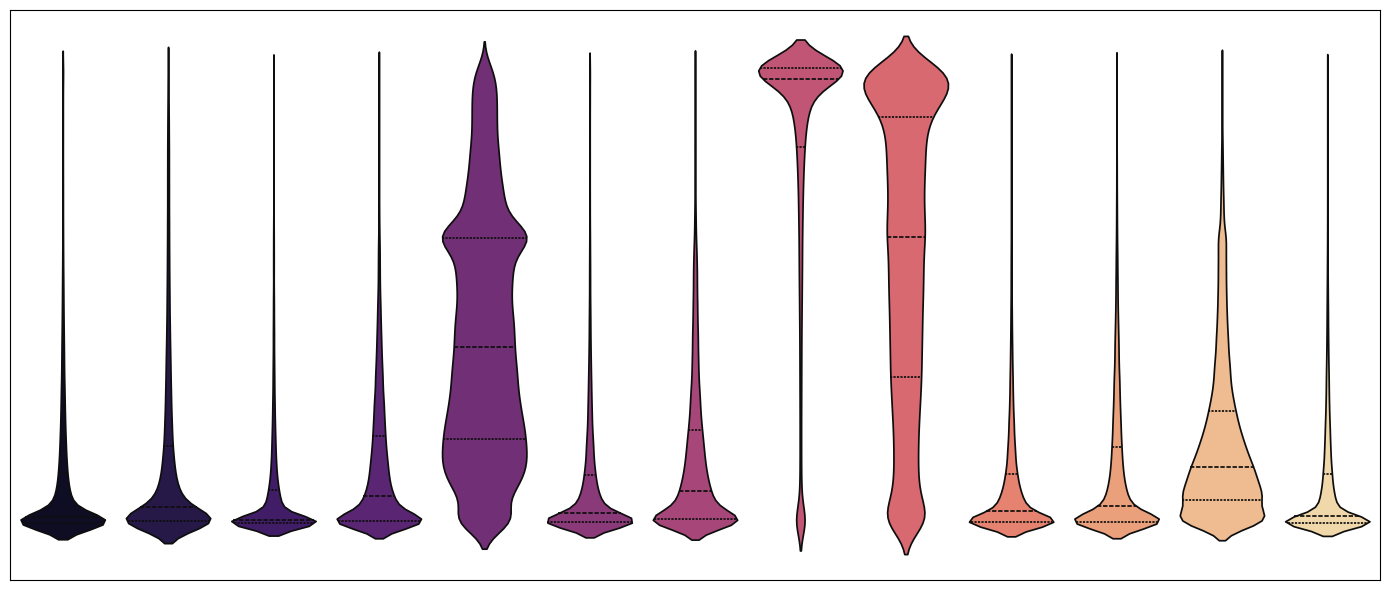

In [5]:
# ==============================================================================
# 2. MAP EFFECT SIZE & PLOT UMAP (WITHOUT LABELS)
# ==============================================================================

# Define your comparison group
comp_group = ["donor_disease_category_UC_disease"]

for i in comp_group:
    # Map the effect size to observations (Ensure alignment matches adata.obs_names)
    adata.obs[i] = de_res.effect_size.sel(covariate=i).values

# Calculate a robust max for the color scale of the effect size
vmax_val = float(np.nanquantile(adata.obs["donor_disease_category_UC_disease"], 0.95))

# Plot UMAP embedding with mapped effect sizes (labels and colorbars removed)
sc.pl.embedding(
    adata,
    basis="umap_mrvi_u",
    color=["donor_disease_category_UC_disease"],
    ncols=2,                   
    layer="data",              
    cmap="viridis", 
    vmax=vmax_val,             
    frameon=False,
    title="",                  # Removes the plot title
    colorbar_loc=None          # Removes the colorbar scale and text
)


# ==============================================================================
# 3. MITOCHONDRIAL PDE VIOLIN PLOT (WITHOUT LABELS)
# ==============================================================================

# Automatically identify mitochondrial genes present in your specific dataset
mt_genes = [g for g in adata.var_names if g.upper().startswith('MT-')]

# Identify the specific covariate string for UC_disease
target_cov = "donor_disease_category_UC_disease"

# Slice the dataset for MT genes AND the specific covariate
mt_pde_uc = ds['pde'].sel(gene=mt_genes, covariate=target_cov)

# Convert to a standard DataFrame for Seaborn plotting
mt_pde_df_uc = mt_pde_uc.to_dataframe(name='pde_value').reset_index()

# Create the Plot
plt.figure(figsize=(14, 6))
sns.violinplot(
    data=mt_pde_df_uc, 
    x='gene', 
    y='pde_value', 
    inner='quartile', 
    palette='magma'
)

# Stripping all labels, text, titles, and ticks
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()